# rerun scCODA for DA model for AIM1

In [1]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad
import os
from sccoda.util import cell_composition_data as dat
from sccoda.util import data_visualization as viz
from sccoda.util import comp_ana as mod
import sccoda.datasets as scd

# warnings.filterwarnings("ignore")

2025-02-13 00:10:10.570355: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1739405411.017766    2462 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1739405411.140940    2462 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-13 00:10:12.872439: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# define working path
data_path = '/home/workspace/private/ra-cohort-ide/ALTRA_revision/frequency_table/'
fig_path = '/home/workspace/private/ra-cohort-ide/ALTRA_revision/frequency_table/figures/'
meta_path = '/home/workspace/github/ra-longitudinal/metadata/'
output_path = '/home/workspace/private/ra-cohort-ide/ALTRA_revision/frequency_table/output_results/'
# os.mkdir(fig_path)
# os.mkdir(output_path)

proj_name = 'ALTRA_scRNA_DA_reanalysis_'

## AIM1

In [3]:
# save aim1 frequency table
aim1_aifi_l3_freq = pd.read_csv(data_path + 'ALTRA_scRNA_AIFI_L3_deepclean_certpro_AIM1_frequency_table.csv')

In [4]:
aim1_aifi_l3_freq.head()

,AIFI_L3_new,sample.sampleKitGuid,counts,pseudo_counts,pseudo_total_counts,subject.subjectGuid,subject.biologicalSex,BMI,CMV_Status_Subj,status,age,file.batchID,Status_Xsec,frequency,pseudo_frequency,pseudo_clr
0,Activated memory B cell,KT00052,0,1,17478,CU1009,Female,24.657159,Negative,at_risk,56,B140,at_risk,0.000000,0.000057,-3.129493
1,Activated memory B cell,KT00056,5,6,12817,CU1007,Female,25.948341,Negative,at_risk,42,B002,at_risk,0.000393,0.000468,-1.334438
2,Activated memory B cell,KT00057,5,6,11946,CU1003,Female,21.126531,Positive,at_risk,21,B002,at_risk,0.000422,0.000502,-1.454036
3,Activated memory B cell,KT00058,3,4,17325,CU1002,Female,27.679501,Positive,at_risk,78,B001,at_risk,0.000174,0.000231,-1.750482
4,Activated memory B cell,KT00060,4,5,11642,CU1005,Female,31.803982,Negative,at_risk,40,B002,at_risk,0.000346,0.000429,-1.265923


In [5]:
# make a count table for scCoda
meta_cols = ['sample_id', 'subject_id', 'batch_id',
             'sex', 'BMI', 'age', 'status']
aim1_count = pd.pivot_table(aim1_aifi_l3_freq.rename(
    columns={"sample.sampleKitGuid":'sample_id', 
             'subject.subjectGuid':'subject_id',
             'file.batchID':'batch_id',
             'subject.biologicalSex': 'sex'}), index=meta_cols, 
                            columns='AIFI_L3_new', values='counts', aggfunc='sum',
                           fill_value=0).reset_index().set_index('sample_id')
aim1_count

AIFI_L3_new,subject_id,batch_id,sex,BMI,age,status,ASDC,ASDC_uk1_B,Activated memory B cell,Activated memory B cell_uk1,...,Proliferating NK cell,Proliferating T cell,SOX4+ Vd1 gdT,SOX4+ naive CD4 T cell,SOX4+ naive CD8 T cell,T2MBC_uk1,Transitional B cell,Type 2 polarized memory B cell,cDC1,pDC
sample_id,,,,,,,,,,,,,,,,,,,,,
KT00052,CU1009,B140,Female,24.657159,56,at_risk,2,3,0,0,...,30,27,5,129,12,1,110,44,4,37
KT00056,CU1007,B002,Female,25.948341,42,at_risk,3,0,5,0,...,31,23,9,43,6,0,146,38,8,21
KT00057,CU1003,B002,Female,21.126531,21,at_risk,4,4,5,0,...,15,17,12,198,49,0,120,27,0,28
KT00058,CU1002,B001,Female,27.679501,78,at_risk,4,2,3,0,...,15,15,2,59,10,0,41,38,5,32
KT00060,CU1005,B002,Female,31.803982,40,at_risk,2,2,4,0,...,12,8,2,20,7,0,95,8,3,34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
KT04671,CU1101,B182,Female,21.541950,41,ALTRA_healthy,3,0,3,0,...,20,7,1,36,11,0,85,8,4,12
KT04905,CU1104,B188,Female,15.464216,23,ALTRA_healthy,5,0,7,0,...,22,11,20,122,29,0,15,36,11,133
KT04906,CU1102,B182,Female,29.283079,24,ALTRA_healthy,2,0,0,0,...,11,4,11,256,57,0,126,31,10,24


In [6]:
meta_cols

['sample_id', 'subject_id', 'batch_id', 'sex', 'BMI', 'age', 'status']

In [7]:
# make sccoda object
aim1_da = dat.from_pandas(aim1_count, covariate_columns=['subject_id','batch_id', 'sex', 'BMI', 'age', 'status'])
aim1_da

AnnData object with n_obs × n_vars = 76 × 89
    obs: 'subject_id', 'batch_id', 'sex', 'BMI', 'age', 'status'

In [8]:
# make metadata coloumnm
from sklearn.preprocessing import scale
aim1_da.obs['scale_age'] = scale(aim1_da.obs['age'])
aim1_da.obs['scale_BMI'] = scale(aim1_da.obs['BMI'])

aim1_da.obs['batch_corr'] = 'other'
aim1_da.obs.loc[aim1_da.obs['batch_id'] == 'B182', 'batch_corr'] = 'B182'

aim1_da.obs['status'] = aim1_da.obs['status'].replace(
    {'at_risk': 'ARI', 'ALTRA_healthy': 'HC'}).astype("category").cat.reorder_categories(['HC', 'ARI'])


In [11]:
aim1_da.obs['status']

sample_id
KT00052    ARI
KT00056    ARI
KT00057    ARI
KT00058    ARI
KT00060    ARI
          ... 
KT04671     HC
KT04905     HC
KT04906     HC
KT04933     HC
KT04937     HC
Name: status, Length: 76, dtype: category
Categories (2, object): ['HC', 'ARI']

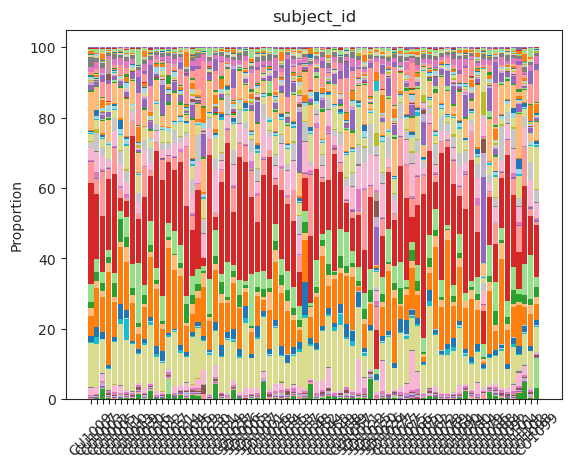

In [12]:
# Stacked barplot for each sample
viz.stacked_barplot(aim1_da, feature_name="subject_id", plot_legend=False)
plt.show()

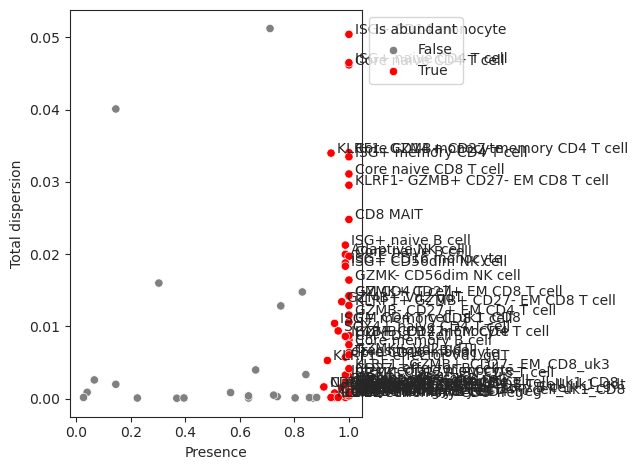

In [13]:
viz.rel_abundance_dispersion_plot(
    data=aim1_da,
    abundant_threshold=0.9
)
plt.show()

/home/workspace/environment/py_scrna/lib/python3.12/site-packages/sccoda/util/data_visualization.py:335: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cell_types, rotation=90)


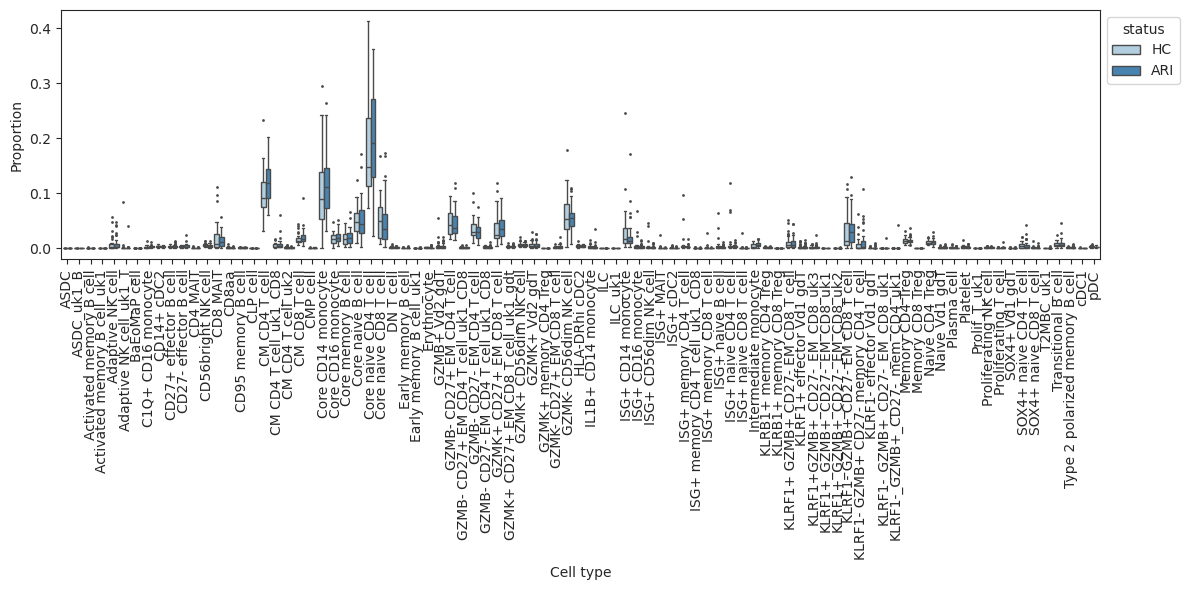

In [14]:
# Grouped boxplots. No facets, relative abundance, no dots.
plt.rcParams['figure.figsize'] = [12, 6]
viz.boxplots(
    aim1_da,
    feature_name="status",
    plot_facets=False,
    y_scale="relative",
    add_dots=False,
)
plt.show()

/home/workspace/environment/py_scrna/lib/python3.12/site-packages/sccoda/util/data_visualization.py:335: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cell_types, rotation=90)


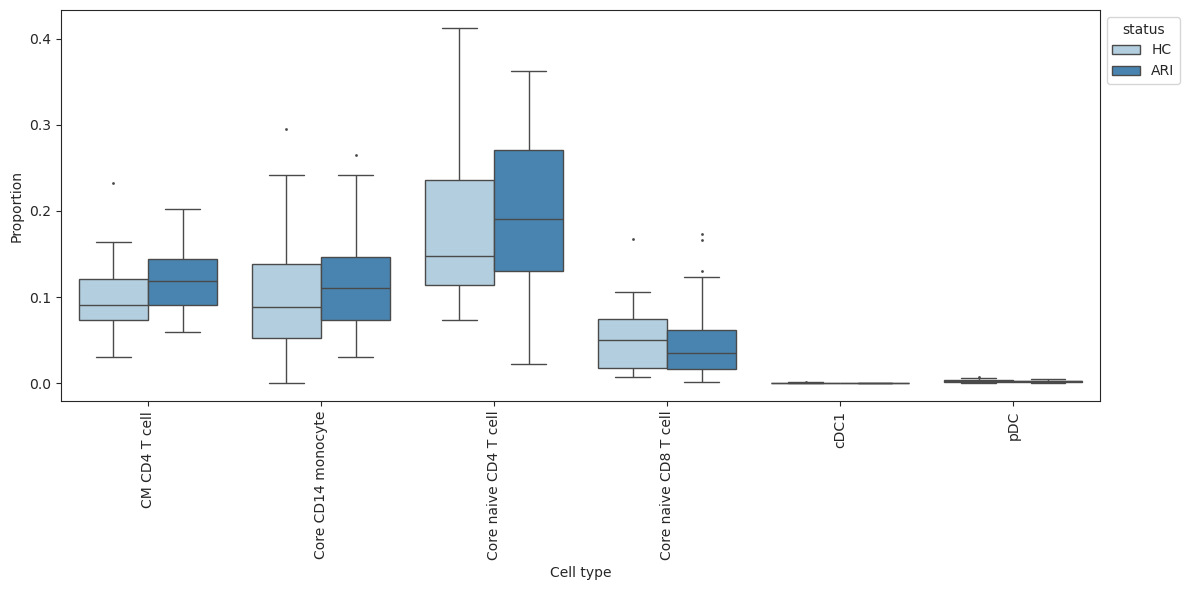

In [15]:
# Grouped boxplots. No facets, relative abundance, no dots.
viz.boxplots(
    aim1_da,
    feature_name="status",
    plot_facets=False,
    y_scale="relative",
    add_dots=False, 
    cell_types=["Core CD14 monocyte", 'CM CD4 T cell', 'Core naive CD8 T cell', 'cDC1',
                'Core naive CD4 T cell', 'pDC']
)
plt.show()

## run sccoda with single reference cell type (test)

In [15]:
# set up sccoda model
aim1_model = mod.CompositionalAnalysis(aim1_da, 
                                       formula="scale_age + sex + scale_BMI + batch_corr + status", 
                                       reference_cell_type= 'pDC')

Zero counts encountered in data! Added a pseudocount of 0.5.


2025-02-11 20:14:19.567063: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [16]:
# Run MCMC
aim1_results = aim1_model.sample_hmc()

  0%|          | 0/20000 [00:00<?, ?it/s]WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
I0000 00:00:1739304861.847103    6105 service.cc:148] XLA service 0x7d3144006f70 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1739304861.847152    6105 service.cc:156]   StreamExecutor device (0): Host, Default Version
2025-02-11 20:14:21.911790: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1739304862.516247    6105 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
100%|██████████| 20000/20000 [05:34<00:00, 59.86it/s]


MCMC sampling finished. (420.586 sec)
Acceptance rate: 60.9%


In [17]:
aim1_results.summary()

Compositional Analysis summary:

Data: 76 samples, 89 cell types
Reference index: 88
Formula: scale_age + sex + scale_BMI + batch_corr + status

Intercepts:
                                Final Parameter  Expected Sample
Cell Type                                                       
ASDC                                     -1.310        26.836725
ASDC_uk1_B                               -1.515        21.862466
Activated memory B cell                  -1.370        25.273876
Activated memory B cell_uk1              -1.688        18.389343
Adaptive NK cell                         -0.084        91.448072
...                                         ...              ...
T2MBC_uk1                                -1.662        18.873735
Transitional B cell                       0.281       131.732229
Type 2 polarized memory B cell           -0.590        55.134260
cDC1                                     -1.087        33.541091
pDC                                      -0.221        79.73999

In [18]:
aim1_results.summary_extended(hdi_prob=0.9)

Compositional Analysis summary (extended):

Data: 76 samples, 89 cell types
Reference index: 88
Formula: scale_age + sex + scale_BMI + batch_corr + status
Spike-and-slab threshold: 0.786

MCMC Sampling: Sampled 20000 chain states (5000 burnin samples) in 420.586 sec. Acceptance rate: 60.9%

Intercepts:
                                Final Parameter  HDI 5%  HDI 95%     SD  \
Cell Type                                                                 
ASDC                                     -1.310  -1.541   -1.073  0.146   
ASDC_uk1_B                               -1.515  -1.761   -1.266  0.150   
Activated memory B cell                  -1.370  -1.620   -1.104  0.157   
Activated memory B cell_uk1              -1.688  -1.973   -1.443  0.163   
Adaptive NK cell                         -0.084  -0.294    0.135  0.133   
...                                         ...     ...      ...    ...   
T2MBC_uk1                                -1.662  -1.913   -1.404  0.158   
Transitional B cell  

In [19]:
aim1_results.set_fdr(est_fdr=0.1)

In [20]:
aim1_results.summary()

Compositional Analysis summary:

Data: 76 samples, 89 cell types
Reference index: 88
Formula: scale_age + sex + scale_BMI + batch_corr + status

Intercepts:
                                Final Parameter  Expected Sample
Cell Type                                                       
ASDC                                     -1.310        26.836725
ASDC_uk1_B                               -1.515        21.862466
Activated memory B cell                  -1.370        25.273876
Activated memory B cell_uk1              -1.688        18.389343
Adaptive NK cell                         -0.084        91.448072
...                                         ...              ...
T2MBC_uk1                                -1.662        18.873735
Transitional B cell                       0.281       131.732229
Type 2 polarized memory B cell           -0.590        55.134260
cDC1                                     -1.087        33.541091
pDC                                      -0.221        79.73999

In [21]:
credible_effects = aim1_results.credible_effects().reset_index()
credible_effects.loc[credible_effects['Covariate'] == 'status[T.ARI]']

,Covariate,Cell Type,Final Parameter
178,status[T.ARI],ASDC,False
179,status[T.ARI],ASDC_uk1_B,False
180,status[T.ARI],Activated memory B cell,False
181,status[T.ARI],Activated memory B cell_uk1,False
182,status[T.ARI],Adaptive NK cell,False
...,...,...,...
262,status[T.ARI],T2MBC_uk1,False
263,status[T.ARI],Transitional B cell,False
264,status[T.ARI],Type 2 polarized memory B cell,False
265,status[T.ARI],cDC1,False


In [22]:
credible_effects['Covariate'].unique()

array(['sex[T.Male]', 'batch_corr[T.other]', 'status[T.ARI]', 'scale_age',
       'scale_BMI'], dtype=object)

In [23]:
effect_df = aim1_results.effect_df.reset_index()
effect_df[(credible_effects['Final Parameter']) & (effect_df['Covariate']=='status[T.ARI]')]

,Covariate,Cell Type,Final Parameter,HDI 3%,HDI 97%,SD,Inclusion probability,Expected Sample,log2-fold change
195,status[T.ARI],CM CD4 T cell,0.182831,0.042,0.324,0.082,0.949533,1601.373321,0.216181
200,status[T.ARI],Core CD14 monocyte,0.171831,-0.002,0.309,0.089,0.951933,1168.664835,0.200312
245,status[T.ARI],KLRF1- GZMB+ CD27- EM CD8 T cell,0.094160,-0.066,0.265,0.090,0.717933,300.649936,0.088257


In [24]:
aim1_results_df = aim1_results.credible_effects().reset_index()
aim1_results_df.loc[(aim1_results_df['Covariate']=='status[T.ARI]') &
    aim1_results_df['Final Parameter']]

,Covariate,Cell Type,Final Parameter
195,status[T.ARI],CM CD4 T cell,True
200,status[T.ARI],Core CD14 monocyte,True
245,status[T.ARI],KLRF1- GZMB+ CD27- EM CD8 T cell,True


In [25]:
# saving model output
aim1_results.save(output_path + 'AIM1_scCODA_models_ref_pDC')

In [23]:
# loading
with open(path, "rb") as f:
    aim1_results = pkl.load((output_path + 'AIM1_scCODA_models_ref_pDC'))

# rotate multiple reference cell types identify differential abundant cell types.
- final results used

In [18]:
ref_cell_stats = pd.read_csv('/home/workspace/private/ra-cohort-ide/ALTRA_revision/DA/output_results/ALTRA_DA_AIM1_wilcox_reference_celltypes.csv')
removed_ref = ['CD8 MAIT', 'DN T cell', 'ISG+ CD14 monocyte', 'ISG+ naive CD4 T cell']
ref_cell_types = ref_cell_stats.loc[~ref_cell_stats['AIFI_L3_new'].isin(removed_ref), 'AIFI_L3_new']
ref_cell_types

1                    Core naive B cell
2                Core naive CD8 T cell
4            GZMB- CD27+ EM CD4 T cell
5                GZMK+ CD56dim NK cell
6                GZMK- CD56dim NK cell
9               KLRB1+ memory CD4 Treg
10    KLRF1+ GZMB+ CD27- EM CD8 T cell
11                                 pDC
Name: AIFI_L3_new, dtype: object

In [19]:
# # set up sccoda model
# aim1_model = mod.CompositionalAnalysis(aim1_da, 
#                                        formula="scale_age + sex + scale_BMI + batch_corr + status", 
#                                        reference_cell_type= 'pDC')

In [21]:
# Run scCODA with each cell type as the reference
cell_types = ref_cell_types
results_cycle = pd.DataFrame()
#results_cycle.index.names = ['ref_cell_type']
for ct in cell_types:
    print(f"Reference: {ct}")
    # Run inference
    model_temp = mod.CompositionalAnalysis(aim1_da, 
                                           formula="scale_age + sex + scale_BMI + batch_corr + status",
                                           reference_cell_type=ct)
    temp_results = model_temp.sample_hmc()
    # set fdr to 0.1
    temp_results.set_fdr(est_fdr=0.1)
    # Select credible effects    
    credible_effects = temp_results.credible_effects().reset_index()
    # output effect df
    effect_df = temp_results.effect_df.reset_index()
    effect_df_fl = effect_df[effect_df['Covariate']=='status[T.ARI]'].copy()
    effect_df_fl['ref_celltype'] = ct
    effect_df_fl['pass_fdr_0_1'] = credible_effects['Final Parameter']
    # add up credible effects
    results_cycle = pd.concat([results_cycle, effect_df_fl])

Reference: Core naive B cell
Zero counts encountered in data! Added a pseudocount of 0.5.


100%|██████████| 20000/20000 [06:52<00:00, 48.45it/s]


MCMC sampling finished. (521.771 sec)
Acceptance rate: 76.0%
Reference: Core naive CD8 T cell
Zero counts encountered in data! Added a pseudocount of 0.5.


100%|██████████| 20000/20000 [07:01<00:00, 47.50it/s]


MCMC sampling finished. (525.887 sec)
Acceptance rate: 58.0%
Reference: GZMB- CD27+ EM CD4 T cell
Zero counts encountered in data! Added a pseudocount of 0.5.


...

MCMC sampling finished. (541.071 sec)
Acceptance rate: 90.2%


/home/workspace/environment/py_scrna/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/workspace/environment/py_scrna/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Reference: pDC
Zero counts encountered in data! Added a pseudocount of 0.5.


100%|██████████| 20000/20000 [07:10<00:00, 46.46it/s]


MCMC sampling finished. (541.760 sec)
Acceptance rate: 56.3%


In [33]:
results_cycle.head()

,Covariate,Cell Type,Final Parameter,HDI 3%,HDI 97%,SD,Inclusion probability,Expected Sample,log2-fold change,ref_celltype,pass_fdr_0_1
178,status[T.ARI],ASDC,0.0,-0.153,0.160,0.061,0.508667,26.926888,-0.039287,Core naive B cell,False
179,status[T.ARI],ASDC_uk1_B,0.0,-0.141,0.161,0.061,0.559867,21.695944,-0.039287,Core naive B cell,False
180,status[T.ARI],Activated memory B cell,0.0,-0.142,0.150,0.049,0.426133,24.956276,-0.039287,Core naive B cell,False
181,status[T.ARI],Activated memory B cell_uk1,0.0,-0.188,0.180,0.066,0.469333,18.212813,-0.039287,Core naive B cell,False
182,status[T.ARI],Adaptive NK cell,0.0,-0.118,0.264,0.083,0.534733,89.221795,-0.039287,Core naive B cell,False


In [36]:
results_cycle_counts = results_cycle[results_cycle['pass_fdr_0_1']].groupby(['ref_celltype']).size()
results_cycle_counts
# remove results using KLRF1+ GZMB+ CD27- EM CD8 T cell as ref

ref_celltype
Core naive B cell                    3
Core naive CD8 T cell                4
GZMB- CD27+ EM CD4 T cell            3
GZMK+ CD56dim NK cell                6
GZMK- CD56dim NK cell                3
KLRB1+ memory CD4 Treg               5
KLRF1+ GZMB+ CD27- EM CD8 T cell    45
pDC                                  3
dtype: int64

In [37]:
# remove results using KLRF1+ GZMB+ CD27- EM CD8 T cell as ref
results_cycle = results_cycle[results_cycle['ref_celltype']!='KLRF1+ GZMB+ CD27- EM CD8 T cell']

In [38]:
results_cycle.head()

,Covariate,Cell Type,Final Parameter,HDI 3%,HDI 97%,SD,Inclusion probability,Expected Sample,log2-fold change,ref_celltype,pass_fdr_0_1
178,status[T.ARI],ASDC,0.0,-0.153,0.160,0.061,0.508667,26.926888,-0.039287,Core naive B cell,False
179,status[T.ARI],ASDC_uk1_B,0.0,-0.141,0.161,0.061,0.559867,21.695944,-0.039287,Core naive B cell,False
180,status[T.ARI],Activated memory B cell,0.0,-0.142,0.150,0.049,0.426133,24.956276,-0.039287,Core naive B cell,False
181,status[T.ARI],Activated memory B cell_uk1,0.0,-0.188,0.180,0.066,0.469333,18.212813,-0.039287,Core naive B cell,False
182,status[T.ARI],Adaptive NK cell,0.0,-0.118,0.264,0.083,0.534733,89.221795,-0.039287,Core naive B cell,False


In [ ]:
results_cycle.to_csv(output_path + proj_name + '_model_results_with_ref_shift.csv')